> **Rama:** `feature/evaluation`
>
> Carga `search`, `X_test`, `y_test` y las listas de columnas desde `src/artifacts/04_modeling.joblib` (generado por `feature/modeling`). Este notebook es el final de la cadena: entrena/guarda el modelo definitivo en `src/models/modelo_dropout_final.joblib`.

In [1]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (classification_report, f1_score, confusion_matrix,
                              ConfusionMatrixDisplay)

src = 'src/artifacts/04_modeling.joblib'
_art = joblib.load(src)
search = _art['search']
X_test = _art['X_test']; y_test = _art['y_test']
numeric_cols = _art['numeric_cols']; nominal_cols = _art['nominal_cols']; binary_cols = _art['binary_cols']

## **Paso 10: Evaluación final contra el conjunto de test**

Con el modelo ya seleccionado y ajustado, lo evaluamos **una única vez** contra el test que hemos
mantenido aparte desde el Paso 5.

In [2]:
final_model = search.best_estimator_

y_pred = final_model.predict(X_test)

f1_macro_test = f1_score(y_test, y_pred, average='macro')
print(f'F1 macro (test): {f1_macro_test:.3f}\n')
print(classification_report(y_test, y_pred))

F1 macro (test): 0.555

              precision    recall  f1-score   support

     Dropout       0.68      0.59      0.63       284
    Enrolled       0.30      0.52      0.38       159
    Graduate       0.72      0.60      0.65       442

    accuracy                           0.58       885
   macro avg       0.57      0.57      0.56       885
weighted avg       0.63      0.58      0.60       885



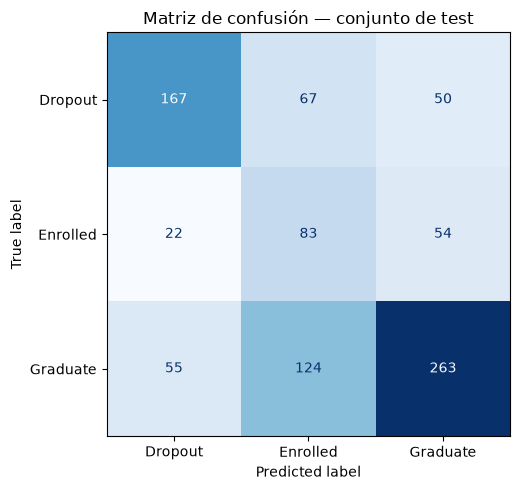

In [3]:
labels_order = ['Dropout', 'Enrolled', 'Graduate']
cm = confusion_matrix(y_test, y_pred, labels=labels_order)

fig, ax = plt.subplots(figsize=(5.5, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_order)
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Matriz de confusión — conjunto de test')
plt.tight_layout()
plt.show()

**Lectura de resultados.** El modelo separa razonablemente bien `Dropout` y `Graduate`
(precision y recall entre 0.58 y 0.72). La clase `Enrolled` es, con diferencia, la más difícil: son
estudiantes cuya trayectoria aún no está definida en el momento de la matrícula (de hecho, aún no lo
está ni siquiera al final de los datos disponibles, porque "Enrolled" significa que siguen estudiando),
así que es esperable que se confundan tanto con `Dropout` como con `Graduate`. Esto es coherente con
la naturaleza del problema y no un fallo del modelo: predecir en el momento 0 quién seguirá
matriculado varios años después es intrínsecamente más incierto que predecir un desenlace ya
consumado.

Con fines de negocio, el resultado más importante es el **recall de `Dropout`**: de los estudiantes
que realmente abandonan, qué proporción detecta el modelo a tiempo. Es la cifra que determina cuántos
estudiantes en riesgo real recibirían apoyo si se desplegara este modelo.

## **Paso 11: Interpretabilidad — variables más influyentes**

Al ser un modelo lineal, podemos inspeccionar directamente los coeficientes para entender qué
variables empujan la predicción hacia cada clase. Mostramos los coeficientes con mayor peso absoluto
para la clase `Dropout`, que es la de mayor interés para el negocio.

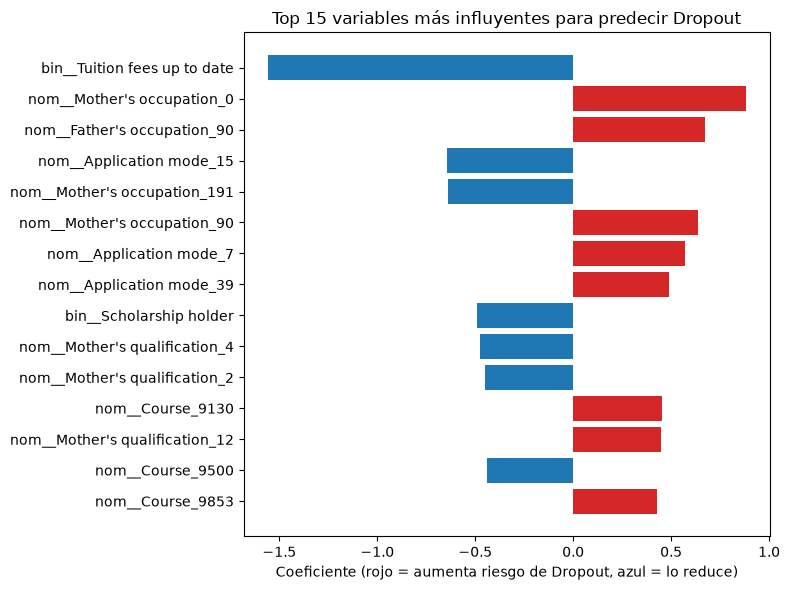

In [4]:
feature_names = final_model.named_steps['pre'].get_feature_names_out()
coefs = final_model.named_steps['clf'].coef_
classes = final_model.named_steps['clf'].classes_

dropout_idx = list(classes).index('Dropout')
coef_df = pd.DataFrame({'feature': feature_names, 'coeficiente': coefs[dropout_idx]})
coef_df['abs_coef'] = coef_df['coeficiente'].abs()
top_features = coef_df.sort_values('abs_coef', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#d62728' if c > 0 else '#1f77b4' for c in top_features['coeficiente']]
ax.barh(top_features['feature'], top_features['coeficiente'], color=colors)
ax.invert_yaxis()
ax.set_xlabel('Coeficiente (rojo = aumenta riesgo de Dropout, azul = lo reduce)')
ax.set_title('Top 15 variables más influyentes para predecir Dropout')
plt.tight_layout()
plt.show()

Esto confirma lo observado en el EDA: la situación económica (`Tuition fees up to date`,
`Scholarship holder`, `Debtor`) y ciertas modalidades de acceso/curso concentran buena parte del peso
predictivo sobre el riesgo de abandono, junto con la edad de matriculación y las notas previas.

## **Paso 12: Guardado del modelo final**

Guardamos el pipeline completo (preprocesamiento + modelo, ya entrenado sobre todo el conjunto de
train) en formato `joblib`, listo para ser cargado en producción sin necesidad de repetir el
preprocesamiento manualmente.

In [5]:
import os
os.makedirs('src/models', exist_ok=True)

model_path = 'src/models/modelo_dropout_final.joblib'
joblib.dump(final_model, model_path)

print(f'Modelo guardado en: {model_path}')

# Verificación de carga
loaded_model = joblib.load(model_path)
print('Verificación — F1 macro test tras recargar el modelo:',
      round(f1_score(y_test, loaded_model.predict(X_test), average='macro'), 3))

Modelo guardado en: src/models/modelo_dropout_final.joblib
Verificación — F1 macro test tras recargar el modelo: 0.555


## **Paso 13: Cómo cargar y usar el modelo guardado**

Esta es la forma recomendada de reutilizar el modelo fuera de este notebook (por ejemplo, en un
script de scoring por lotes o en una API): se carga el pipeline completo con `joblib.load` y se le
pasan datos nuevos con las mismas columnas usadas en el entrenamiento. No hace falta repetir a mano
el escalado ni el one-hot: todo el preprocesamiento va incluido dentro del pipeline guardado.

In [6]:
# Columnas que espera el modelo (las mismas de X_train, en cualquier orden)
columnas_modelo = numeric_cols + nominal_cols + binary_cols
print(f'El modelo espera {len(columnas_modelo)} columnas:')
print(columnas_modelo)

# --- Ejemplo de uso con datos "nuevos" ---
# En un caso real, X_nuevo vendría de un fichero o base de datos distinto;
# aquí usamos unas filas de test como ejemplo de estudiantes recién matriculados.
modelo_cargado = joblib.load(model_path)

X_nuevo = X_test[columnas_modelo].head(5)
pred_nuevo = modelo_cargado.predict(X_nuevo)
proba_nuevo = modelo_cargado.predict_proba(X_nuevo)

resultado = X_nuevo.copy()
resultado['prediccion'] = pred_nuevo
for i, clase in enumerate(modelo_cargado.named_steps['clf'].classes_):
    resultado[f'prob_{clase}'] = proba_nuevo[:, i].round(3)

resultado[['prediccion'] + [f'prob_{c}' for c in modelo_cargado.named_steps['clf'].classes_]]

El modelo espera 20 columnas:
['Previous qualification (grade)', 'Admission grade', 'Age at enrollment', 'Unemployment rate', 'GDP', 'Marital status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance', 'Previous qualification', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Displaced', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder']


,prediccion,prob_Dropout,prob_Enrolled,prob_Graduate
1853,Enrolled,0.168,0.469,0.363
2399,Graduate,0.240,0.352,0.408
510,Graduate,0.106,0.426,0.467
242,Graduate,0.123,0.374,0.504
3392,Graduate,0.050,0.117,0.833


## **Paso 14: Conclusiones y próximos pasos**

**Resumen del proceso:**
- Se descartaron las variables `Curricular units` por data leakage (predicen casi perfectamente el
  target porque se conocen después del hecho), priorizando un modelo útil para intervención temprana
  frente a uno con métricas infladas.
- Se descartaron `Nacionality`, `Educational special needs`, `International` e `Inflation rate` por
  no ser significativas en el EDA.
- Se usó **F1 macro** como métrica principal por el desbalance moderado de clases, y
  `class_weight='balanced'` como estrategia de balanceo (equivalente a SMOTE en este caso, pero más
  simple).
- **Logistic Regression** fue el modelo elegido: rendimiento a la par del mejor modelo de la
  comparativa (SVM) pero con la ventaja de ser interpretable y más rápido de ajustar.
- F1 macro final en test: **ver resultado impreso en el Paso 10** (bastante por encima del baseline
  y en línea con lo obtenido en validación cruzada, sin señales de sobreajuste).

**Limitaciones:**
- La clase `Enrolled` sigue siendo difícil de predecir, algo esperable dado que representa una
  situación aún no resuelta en el momento de la matrícula.
- El modelo no usa ningún dato posterior a la matrícula; un sistema de alerta temprana en producción
  podría combinarse con un segundo modelo (usando datos de 1er semestre) para recalibrar el riesgo a
  mitad de curso, asumiendo conscientemente el leakage/ventana temporal más corta que eso implica.

**Posibles acciones de mejora (ya evaluadas o para futuras iteraciones):**
- Probar un ensamblado (stacking) de Logistic Regression + SVM, dado que ambos capturan patrones
  ligeramente distintos según la matriz de confusión.
- Explorar ingeniería de variables adicionales a partir de las combinaciones padre/madre
  (cualificación + ocupación) para resumir el capital socioeconómico familiar en menos variables y
  reducir la dimensionalidad del one-hot.
